In [1]:
import sys
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from typing import Tuple
import pandas
import seaborn

In [2]:
sys.path.append("/home/alexis/Documents/COMP558/COMP558-FinalProject/code/")
# sys.path.append("/workspaces/python-opencv/repo/code/")

In [3]:
from tracker import Tracker
from optical_flow.bounding_box import BoundingBox
from feature_detection.shi_tomasi import ShiTomasiDetector
from feature_description.orb_descriptor import ORBDescriptor
from optical_flow.lucas_kanade import LucasKanade
from segmentation.fuzzy_c_means import FuzzyCMeansSegmenter

In [4]:
video_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/VIDEO-20250115-212202.mp4"
depth_name = "/home/alexis/Documents/master/vision/repo/libfreenect/wrappers/python/out/DEPTH-20250115-212202.mp4"

output_name = "out/complete7.mp4"

In [5]:
x, y, w, h = 270, 260, 100, 75

shi_tomasi_params = {"params" : {"maxCorners" : 1000, "qualityLevel" : 0.01, "minDistance" : 5, "blockSize" : 5}}
orb_params = {"params": {"nfeatures" : 1000, "edgeThreshold" : 15, "patchSize" : 10}}
gu_params = {"_lambda" : 4/5, "frame_buffer" : 60, "gamma" : 0.1, "gamma_fit" : 1, "gamma_area" : 0.1, "gamma_drift" : 0.5}
lucas_kanade_params = {}
c_means_params = {"n_groups" : 1, "target_error" : 0, "neighbourhood_size" : 10, "m" : 2, "lambda_val" : 2, "max_iter" : 1}

In [6]:
initial_bbox = BoundingBox(x, y, w, h)

feature_detector = ShiTomasiDetector(**shi_tomasi_params)
feature_descriptor = ORBDescriptor(**orb_params)
optical_flow = LucasKanade(**lucas_kanade_params)
segmenter = FuzzyCMeansSegmenter(**c_means_params)

In [7]:
cap_video = cv.VideoCapture(video_name)
cap_depth = cv.VideoCapture(depth_name)

ret_video, frame_video = cap_video.read()
ret_depth, frame_depth = cap_depth.read()

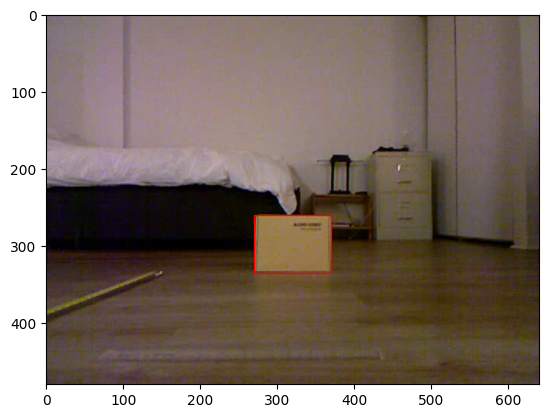

In [8]:
fig, ax = plt.subplots()

ax.imshow(frame_video[:,:,::-1])

rect = patches.Rectangle((initial_bbox.x, initial_bbox.y), initial_bbox.w, initial_bbox.h, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [9]:
tracker = Tracker(frame_video, initial_bbox, feature_detector, optical_flow, feature_descriptor, segmenter, gu_params)

In [10]:
fps = cap_video.get(cv.CAP_PROP_FPS)

fourcc = cv.VideoWriter_fourcc(*'mp4v')
video_writer = cv.VideoWriter(output_name, fourcc, fps, frame_video.shape[:-1][::-1])

In [11]:
minDistance = -10
scaleFactor = 0.0021

def img_to_coord(depth : np.ndarray):

    distance = 100/(-0.00307 * depth * (2 ** 2) + 3.33)

    img_h, img_w = depth.shape[0:2]

    a = np.arange(img_w)
    b = np.arange(img_h)

    i, j = np.meshgrid(a, b)

    z = distance
    x = (i - img_w / 2) * (z + minDistance) * scaleFactor
    y = (j - img_h / 2) * (z + minDistance) * scaleFactor

    return np.dstack([x, y, z])

In [12]:
kernel = np.ones((3, 3), np.uint8)
blockSize = 201
C = 2
morphIter = 3

inlay = 1/3

def get_roi_3d_coordinate(depth_frame : np.ndarray, bbox : BoundingBox) -> Tuple[float, float, float]:
    gray = cv.cvtColor(depth_frame, cv.COLOR_BGR2GRAY)

    coords = img_to_coord(gray)[int(bbox.y + inlay * bbox.h):int(bbox.y + (1 - inlay) * bbox.h), int(bbox.x + inlay * bbox.w):int(bbox.x + (1 - inlay) * bbox.w), ...]

    return np.mean(coords, axis = (0, 1))


In [13]:
length = int(cap_video.get(cv.CAP_PROP_FRAME_COUNT))

bbox_loc = np.zeros((length, 4))
point_loc = np.zeros((length, 3))

for i in tqdm(range(length)):

    if not (ret_video and ret_depth):
        break

    bbox = tracker.track(frame_video)
    bbox_loc[i, :] = [bbox.x, bbox.y, bbox.w, bbox.h]
    point_loc[i, :] = get_roi_3d_coordinate(frame_depth, bbox)

    img2 = cv.rectangle(frame_video, (bbox.x, bbox.y), (bbox.x + bbox.w, bbox.y + bbox.h), 255, 2)

    video_writer.write(img2)

    ret_video, frame_video = cap_video.read()
    ret_depth, frame_depth = cap_depth.read()

100%|██████████| 472/472 [00:15<00:00, 31.26it/s]


In [14]:
video_writer.release()

[Text(0.5, 1.0, 'Coordinates of tracked object'),
 Text(0.5, 0, 'Frame number'),
 Text(0, 0.5, 'Coordinate (cm)')]

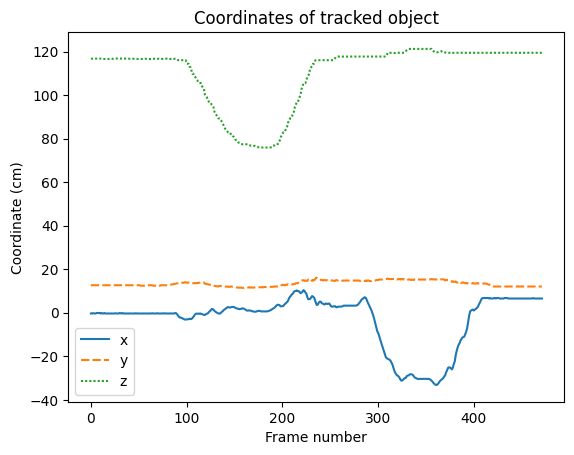

In [15]:
df = pandas.DataFrame(point_loc.copy(), columns = ('x', 'y', 'z'))

# remove outliers
df.loc[df['z'] > 200] = np.nan
df = df.interpolate(method='linear')


seaborn.lineplot(df).set(title = "Coordinates of tracked object", 
                         xlabel = "Frame number", 
                         ylabel = "Coordinate (cm)")